# GSE242889 HCC tumor samples: PGAM5-associated macrophage candidates

All five tumor samples 1T-5T are included without MVI filtering. Adjacent NT samples are excluded, following the preceding tumor-only analysis scope. GEO describes three MVI-present and two MVI-absent patients but its sample characteristics do not label individual samples by MVI; no sample-level assignment is invented.

## Methods and annotation assumptions

GEO supplies sample count matrices without author cell-type labels. Exploratory annotation uses normalized, log1p all-tumor QC cells: 2000 Seurat HVGs (PGAM5 excluded), 30 PCs, 15 neighbors, igraph Leiden resolution 1, random seed 0. Cluster marker review identifies macrophage clusters with C1QA/B/C each detected in >=75%, CSF1R>=60%, TYROBP>=90%, CD1C<40%, FCN1<50%. These are **marker-inferred C1Q-rich macrophages**, not author labels and not guaranteed to capture all C1Q-low macrophages. CD1C/FCER1A-rich dendritic and FCN1-rich monocyte clusters are excluded. Marker rules are exploratory decisions after target-agnostic review; no clustering features use PGAM5.

Basic QC: >=500 detected genes and <20% mitochondrial counts. Matrices are combined by outer union of Ensembl IDs, with absent feature rows filled as zeros. Input gene lists differ, which may introduce technical heterogeneity; no batch integration or technical covariate model is claimed.

PGAM5 raw count >0 defines RNA-detected cells, count=0 means nondetection, not protein negativity. Selected macrophages are pooled, normalized to 10,000, log1p transformed, and compared by Wilcoxon with tie correction, BH across all genes. No patient pairing, depth matching or sample/MVI/depth covariates.

Thresholds: FDR<0.05, |Scanpy approximate log2FC|>=1, >=10% detection in either group. PGAM5 remains in full and passing tables but is excluded from up/down candidates. Ribosomal and mitochondrial genes remain eligible. Approximate fold change is based on back-transformed mean log expression, not arithmetic means.

Sources: [GEO GSE242889](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE242889), official sample archives linked in family SOFT. PMID 37972953. The archives have .tar.gz names but are plain POSIX tar files; extraction checks paths and rejects symbolic/hard links.

Candidates are exploratory. The strong ALB RNA background in this dataset remains unresolved: ambient RNA, phagocytosed material and doublets are not distinguished or corrected. Cell-level FDR does not demonstrate patient-level reproducibility, macrophage specificity or causal function.


In [1]:
from pathlib import Path
import json,numpy as np,pandas as pd,anndata as ad
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from IPython.display import display
R=Path.cwd();s=json.loads((R/'analysis_summary.json').read_text())
a=ad.read_h5ad(R/'macrophage_counts_QC.h5ad')
r=pd.read_csv(R/'GSE242889_HCC_tumor_PGAM5_full_DE.csv',index_col=0)
u=pd.read_csv(R/'GSE242889_HCC_tumor_PGAM5_upregulated.csv',index_col=0)
d=pd.read_csv(R/'GSE242889_HCC_tumor_PGAM5_downregulated.csv',index_col=0)
assert set(a.obs.Sample)=={'1T','2T','3T','4T','5T'}
assert a.obs.n_genes.ge(500).all() and a.obs.pct_mt.lt(20).all()
assert a.obs_names.is_unique and a.var_names.is_unique
q=pd.read_csv(R/'cluster_annotation_decisions.csv',dtype={'cluster':str})
assert set(a.obs.leiden.astype(str))==set(q.loc[q.included_as_macrophage,'cluster'])
pg=np.flatnonzero(a.var.gene.eq('PGAM5'));assert len(pg)==1
pos=a.X[:,pg[0]].toarray().ravel()>0
assert np.array_equal(pos,a.obs.PGAM5_detected)
assert int(pos.sum())==s['PGAM5_positive_cells'] and int((~pos).sum())==s['PGAM5_undetected_cells']
assert len(a)==s['QC_inferred_macrophages']
assert np.allclose(multipletests(r.p_value,method='fdr_bh')[1],r.FDR,atol=1e-12)
eligible=r.FDR.lt(.05)&r[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)&~r.gene.eq('PGAM5')
assert set(u.index)==set(r.index[eligible&r.log2FC.ge(1)])
assert set(d.index)==set(r.index[eligible&r.log2FC.le(-1)])
checks=[];totals=np.asarray(a.X.sum(axis=1)).ravel()
for i in u.index[:10]:
 raw=a.X[:,a.var_names.get_loc(i)].toarray().ravel();v=np.log1p(raw/totals*1e4)
 pv=mannwhitneyu(v[pos],v[~pos],method='asymptotic',alternative='two-sided',use_continuity=False).pvalue
 fc=np.log2((np.expm1(v[pos].mean())+1e-9)/(np.expm1(v[~pos].mean())+1e-9))
 assert np.isclose(pv,r.loc[i,'p_value'],rtol=.002,atol=1e-12)
 assert np.isclose(fc,r.loc[i,'log2FC'],atol=.002)
 assert np.isclose((raw[pos]>0).mean(),r.loc[i,'fraction_PGAM5_positive'])
 checks.append({'gene':r.loc[i,'gene'],'SciPy_p':pv,'Scanpy_p':r.loc[i,'p_value'],'recomputed_log2FC':fc,'reported_log2FC':r.loc[i,'log2FC']})
pd.DataFrame(checks).to_csv(R/'independent_calculation_checks.csv',index=False)
print('Scope, QC, annotation membership, raw PGAM5 grouping, BH and full candidate memberships verified.')
display(pd.DataFrame(checks));display(pd.Series(s,name='value').to_frame())
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':120,'savefig.bbox':'tight'})


Scope, QC, annotation membership, raw PGAM5 grouping, BH and full candidate memberships verified.


,gene,SciPy_p,Scanpy_p,recomputed_log2FC,reported_log2FC
0,SLC39A11,2.386890e-08,2.386890e-08,1.385586,1.385586
1,RIC8A,2.791699e-08,2.791699e-08,1.247835,1.247835
2,FLNA,1.134344e-07,1.134344e-07,1.133819,1.133819
3,FEN1,1.158591e-07,1.158591e-07,1.640684,1.640684
4,CDC23,2.718264e-07,2.718264e-07,1.304510,1.304510
5,CLSTN1,2.790574e-07,2.790574e-07,1.228435,1.228435
6,MMP2,9.094495e-07,9.094495e-07,1.981605,1.981605
7,ANPEP,9.043716e-07,9.043716e-07,1.172571,1.172571
8,AP4S1,9.645604e-07,9.645604e-07,1.516463,1.516463
9,SERPINA4,9.850096e-07,9.850096e-07,1.382218,1.382218


,value
HCC_tumor_samples,5
HCC_tumor_patients,5
source_tumor_cells,32955
QC_tumor_cells,19872
QC_inferred_macrophages,4891
PGAM5_positive_cells,138
PGAM5_undetected_cells,4753
samples_with_macrophages,5
samples_with_positive_macrophages,5
tested_genes,58336


## Annotation audit

Macrophages are inferred from concordant C1Q, CSF1R and TYROBP expression rather than PGAM5. The chart also shows three dendritic-like clusters and one monocyte-like cluster to make exclusions inspectable. These labels are exploratory and do not establish complete macrophage subtype coverage.


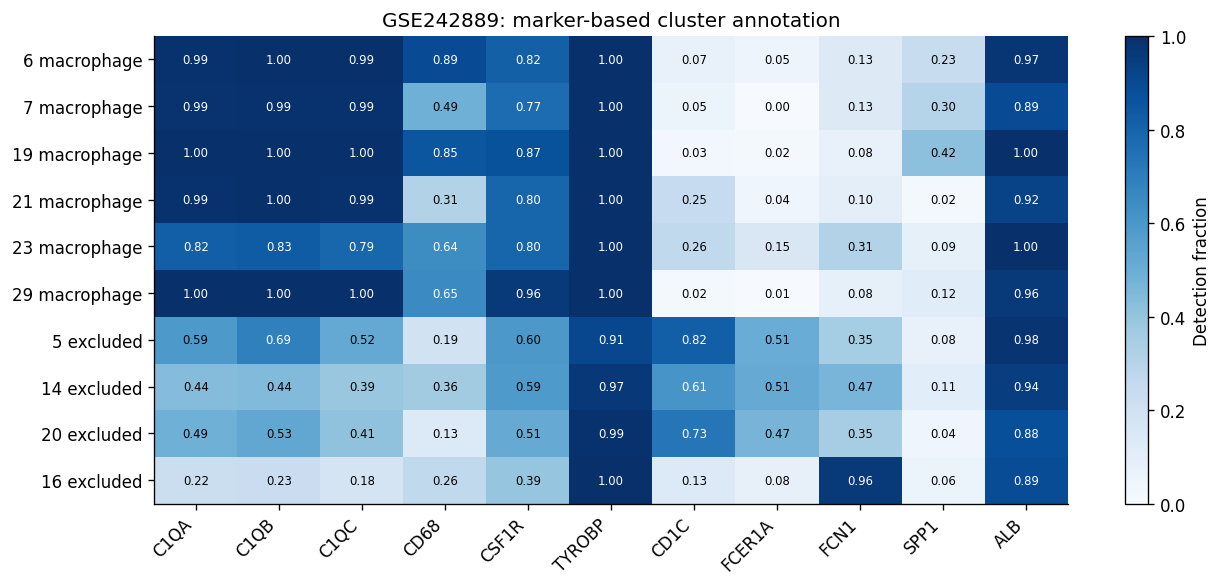

,cluster,cells,fraction_C1QA,fraction_C1QB,fraction_C1QC,fraction_CD68,fraction_CSF1R
6,6,686,0.988338,0.995627,0.994169,0.892128,0.816327
7,7,827,0.987908,0.989117,0.991536,0.488513,0.766626
19,19,553,1.000000,1.000000,1.000000,0.851718,0.869801
21,21,1113,0.991914,0.997305,0.989218,0.312668,0.795148
23,23,1316,0.818389,0.831307,0.789514,0.641337,0.796353
29,29,396,1.000000,1.000000,1.000000,0.648990,0.959596


In [2]:
q=pd.read_csv(R/'cluster_annotation_decisions.csv',dtype={'cluster':str})
cl=s['macrophage_clusters']+['5','14','20','16']
genes=['C1QA','C1QB','C1QC','CD68','CSF1R','TYROBP','CD1C','FCER1A','FCN1','SPP1','ALB']
t=q.set_index('cluster').loc[cl,['fraction_'+g for g in genes]]
fig,ax=plt.subplots(figsize=(11,5));im=ax.imshow(t.to_numpy(),vmin=0,vmax=1,cmap='Blues',aspect='auto')
ax.set_xticks(range(len(genes)),genes,rotation=45,ha='right')
ax.set_yticks(range(len(cl)),[i+(' macrophage' if i in s['macrophage_clusters'] else ' excluded') for i in cl])
for i in range(len(cl)):
 for j in range(len(genes)):
  z=t.iloc[i,j];ax.text(j,i,f'{z:.2f}',ha='center',va='center',fontsize=7,color='white' if z>.6 else 'black')
ax.set_title('GSE242889: marker-based cluster annotation');fig.colorbar(im,ax=ax,label='Detection fraction')
fig.tight_layout();fig.savefig(R/'cluster_annotation_QA.png');fig.savefig(R/'cluster_annotation_QA.pdf');plt.show()
display(q[q.included_as_macrophage][['cluster','cells']+['fraction_'+g for g in ['C1QA','C1QB','C1QC','CD68','CSF1R']]])


## PGAM5 detection support

All five tumor samples are eligible irrespective of MVI. Rates use inferred macrophages as the denominator. Samples may contribute unequal numbers of cells; no balancing is performed.


,Sample,macrophages,PGAM5_positive,rate
0,1T,689,11,0.015965
1,2T,569,34,0.059754
2,3T,1118,30,0.026834
3,4T,1306,39,0.029862
4,5T,1209,24,0.019851


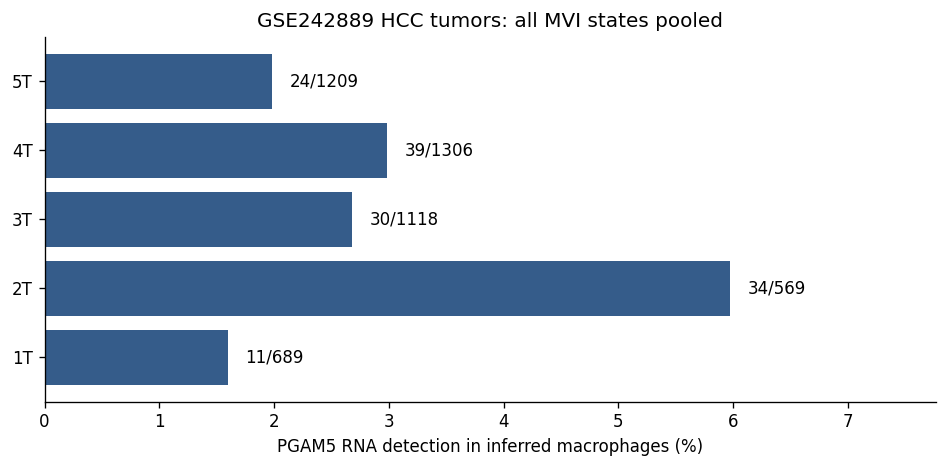

group,PGAM5_detected,PGAM5_undetected
gene,,
ALB,0.964,0.957
APOA1,0.870,0.764
C1QA,0.942,0.946
C1QB,0.957,0.951
C1QC,0.942,0.939
CD3D,0.051,0.053
CD68,0.754,0.596
CSF1R,0.848,0.814
EPCAM,0.000,0.001


In [3]:
t=pd.read_csv(R/'PGAM5_by_sample.csv');display(t)
fig,ax=plt.subplots(figsize=(8,4));ax.barh(t.Sample,t.rate*100,color='#355C8A')
for i,z in t.iterrows():ax.text(z.rate*100+.15,i,f'{z.PGAM5_positive}/{z.macrophages}',va='center')
ax.set_xlim(0,max(5,t.rate.max()*100*1.3));ax.set_xlabel('PGAM5 RNA detection in inferred macrophages (%)')
ax.set_title('GSE242889 HCC tumors: all MVI states pooled');fig.tight_layout()
fig.savefig(R/'PGAM5_detection_by_sample.png');fig.savefig(R/'PGAM5_detection_by_sample.pdf');plt.show()
display(pd.read_csv(R/'TAM_marker_QA.csv').pivot(index='gene',columns='group',values='fraction').round(3))


## Differential candidates

Volcano includes genes detected in >=10% of either group, excluding the defining PGAM5 gene. Orange/blue denote up/down candidates; gray denotes others. Gene candidates may reflect technical or patient/subtype differences and unresolved ambient RNA.


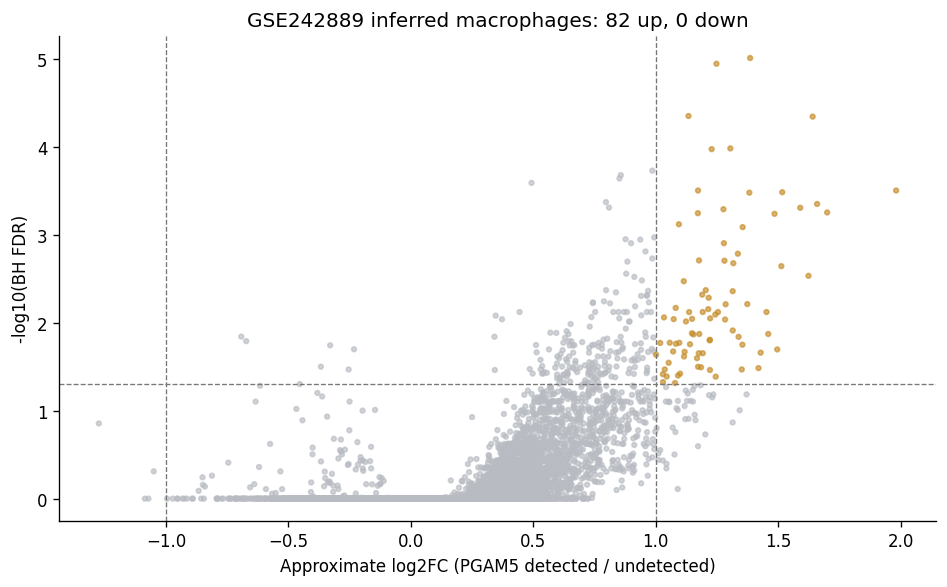

,gene,log2FC,FDR,fraction_PGAM5_positive,fraction_PGAM5_undetected
names,,,,,
ENSG00000133195,SLC39A11,1.385586,0.000010,0.202899,0.072165
ENSG00000177963,RIC8A,1.247835,0.000011,0.275362,0.116137
ENSG00000196924,FLNA,1.133819,0.000045,0.413043,0.220703
ENSG00000168496,FEN1,1.640684,0.000046,0.123188,0.035136
ENSG00000094880,CDC23,1.304510,0.000105,0.181159,0.065853
ENSG00000171603,CLSTN1,1.228435,0.000107,0.253623,0.109194
ENSG00000087245,MMP2,1.981605,0.000316,0.101449,0.028403
ENSG00000166825,ANPEP,1.172571,0.000316,0.275362,0.127919
ENSG00000100478,AP4S1,1.516463,0.000330,0.115942,0.034925


,gene,log2FC,FDR,fraction_PGAM5_positive,fraction_PGAM5_undetected
names,,,,,


In [4]:
t=r[r[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)&~r.gene.eq('PGAM5')]
color=np.where(t.FDR.lt(.05)&t.log2FC.ge(1),'#C68D29',np.where(t.FDR.lt(.05)&t.log2FC.le(-1),'#355C8A','#B8BCC2'))
fig,ax=plt.subplots(figsize=(8,5));ax.scatter(t.log2FC,-np.log10(t.FDR.clip(lower=1e-300)),s=8,c=color,alpha=.65)
ax.axhline(-np.log10(.05),ls='--',color='#777',lw=.8)
for x in [-1,1]:ax.axvline(x,ls='--',color='#777',lw=.8)
ax.set_xlabel('Approximate log2FC (PGAM5 detected / undetected)');ax.set_ylabel('-log10(BH FDR)')
ax.set_title(f'GSE242889 inferred macrophages: {len(u)} up, {len(d)} down')
fig.tight_layout();fig.savefig(R/'differential_expression.png');fig.savefig(R/'differential_expression.pdf');plt.show()
display(u[['gene','log2FC','FDR','fraction_PGAM5_positive','fraction_PGAM5_undetected']].head(20))
display(d[['gene','log2FC','FDR','fraction_PGAM5_positive','fraction_PGAM5_undetected']].head(20))


## Reproduction and limits

Download five official tumor archives plus family SOFT; extract as plain tar after path checks. Install versions listed in environment_versions.txt. Run prepare_annotation.py, analyze_PGAM5.py, then build_notebook.py. The ZIP contains output tables, annotation decisions, plots, hashes, code and this executed notebook, not full raw or QC matrices. Reexecuting the analysis scripts generates the QC count files used for notebook checks.

The analysis is exploratory and uses inferred C1Q-rich macrophages. Strong ALB background, missing author labels, heterogeneous feature lists, patient/subtype/depth effects and incomplete C1Q-low coverage limit biological interpretation. No validated signature or independent functional validation is claimed.
